# Portrait Extraction — Step-by-Step Debug Notebook

This notebook extracts oval portraits from scanned book pages.
Each step visualizes its output so you can verify the pipeline at every stage.

**Folder expectations:**
- Input: `./pages_as_images/*.png`
- Output: `./contour_portraits/` (RGBA PNGs with transparent background)

`SAMPLE_PAGE` below is auto-set to the first PNG found — change it as needed.

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Config ────────────────────────────────────────────────────────────────────
PAGES_DIR  = Path('./pages_as_images')
OUTPUT_DIR = Path('./contour_portraits')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_PAGE_NR = 15
SAMPLE_PAGE = next(PAGES_DIR.glob(f'page_{SAMPLE_PAGE_NR}.png'), None)
print(f'Using sample page: {SAMPLE_PAGE}')

# ── Tuning knobs — adjust these to match your scans ──────────────────────────
AREA_MIN        = 50_000   # ignore contours smaller than this (noise)
AREA_MAX        = 5_000_000  # ignore contours larger than this (full-page blobs)
TARGET_HW_RATIO = 1.28     # expected height/width ratio of portraits
HW_TOLERANCE    = 0.20     # accept ratios within ±this of the target
PADDING         = 0       # extra pixels around the bounding box when cropping

def show(img, title='', info='', cmap=None, figsize=(10, 8), legend_patches=None):
    fig, ax = plt.subplots(figsize=figsize)
    converted_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(converted_image)
    ax.set_title(title, fontsize=13)
    ax.axis('off')
    if legend_patches:
        ax.legend(handles=legend_patches, loc='upper right', fontsize=10)
    if info:
        fig.text(0.5, 0.01, info, ha='center', fontsize=11, color='#333333')
    plt.tight_layout()
    plt.show()

Using sample page: pages_as_images\page_15.png


## Step 1 — Load the page

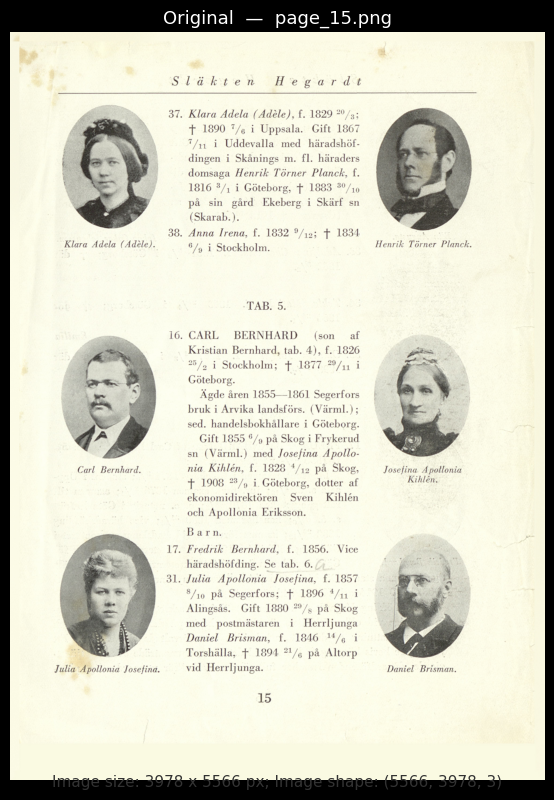

In [28]:
assert SAMPLE_PAGE is not None, 'No PNG files found in ./pages_as_images'

img = cv2.imread(str(SAMPLE_PAGE))  # always use this, never plt.imread
print(img.shape)        # (5425, 3863, 3) ✓
print(img[0, 0, :])     # print top-left pixel — if R > B it's probably RGB not BGR
assert img is not None, f'Could not read {SAMPLE_PAGE}'

h, w = img.shape[:2]
show(img, f'Original  —  {SAMPLE_PAGE.name}', info=f'Image size: {w} x {h} px; Image shape: {img.shape}')

## Step 2 — Grayscale + Gaussian blur

Blurring reduces paper-texture noise so the threshold step produces cleaner blobs.

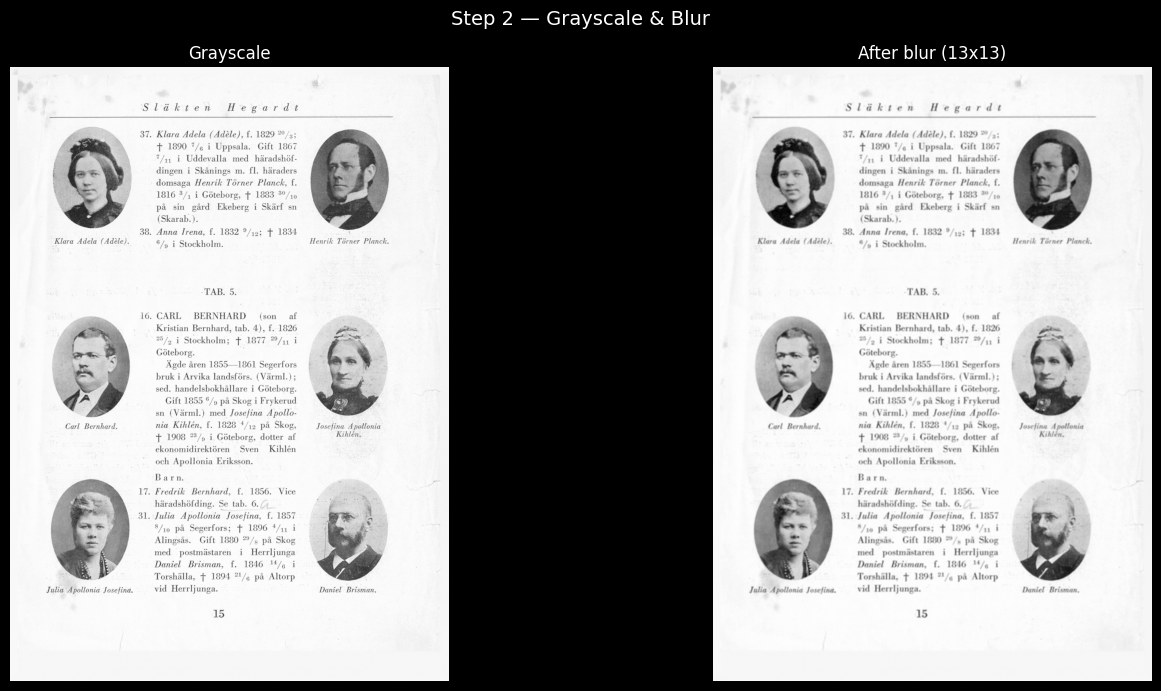

In [29]:
gray    = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.blur(gray, (13, 13))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(gray,    cmap='gray'); axes[0].set_title('Grayscale');       axes[0].axis('off')
axes[1].imshow(blurred, cmap='gray'); axes[1].set_title('After blur (13x13)'); axes[1].axis('off')
plt.suptitle('Step 2 — Grayscale & Blur', fontsize=14)
plt.tight_layout()
plt.show()

## Step 3 — OTSU threshold

`THRESH_BINARY_INV` makes dark content (portraits, text) **white** so they become
filled blobs that contour-finding can latch onto. OTSU picks the split value automatically.

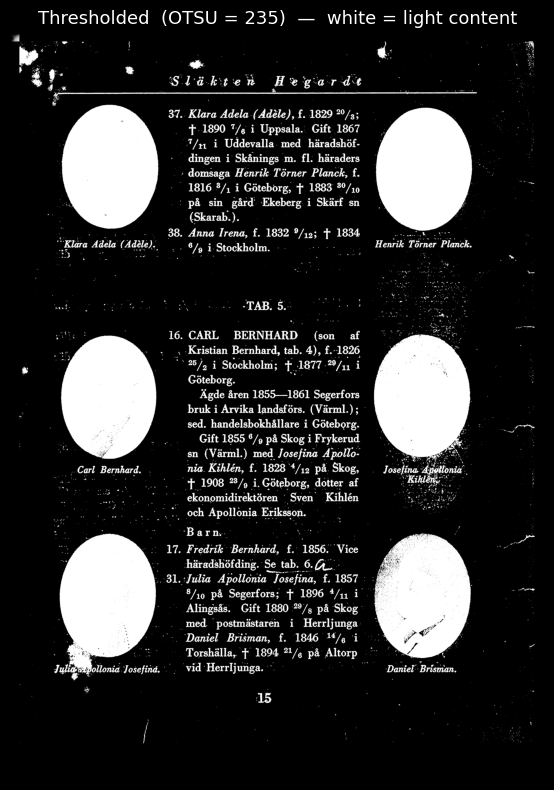

In [35]:
thresh_val, thresh = cv2.threshold(gray, 235, 255, cv2.THRESH_BINARY_INV)
show(thresh, f'Thresholded  (OTSU = {thresh_val:.0f})  —  white = light content')

## Step 4 — Find & draw all external contours

Red = every external contour found. The next step filters these down.

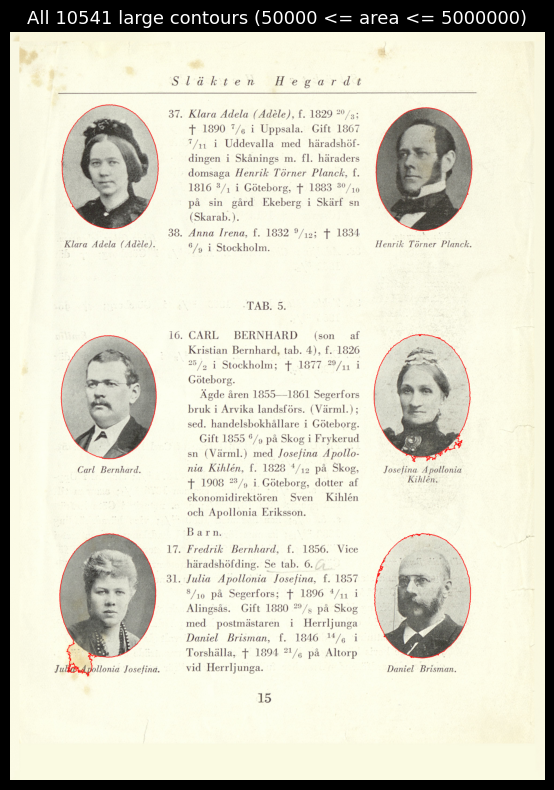

In [36]:
contours, _ = cv2.findContours(thresh, cv2.RETR_TREE , cv2.CHAIN_APPROX_NONE)
large_contours = [cont for cont in contours if (AREA_MIN <= cv2.contourArea(cont) <= AREA_MAX)]
debug_all = img.copy()
cv2.drawContours(debug_all, large_contours, -1, (0, 0, 255), 4)
show(debug_all, f'All {len(contours)} large contours ({AREA_MIN} <= area <= {AREA_MAX})')

## Step 5 — Filter by area and height/width ratio

A contour is accepted only when:
1. Its pixel area is in `[AREA_MIN, AREA_MAX]`
2. The bounding-box height/width ratio is within `HW_TOLERANCE` of `TARGET_HW_RATIO` (1.28)

**Green** = accepted portrait  
**Orange** = area OK but wrong shape  
**Grey** = filtered out by area

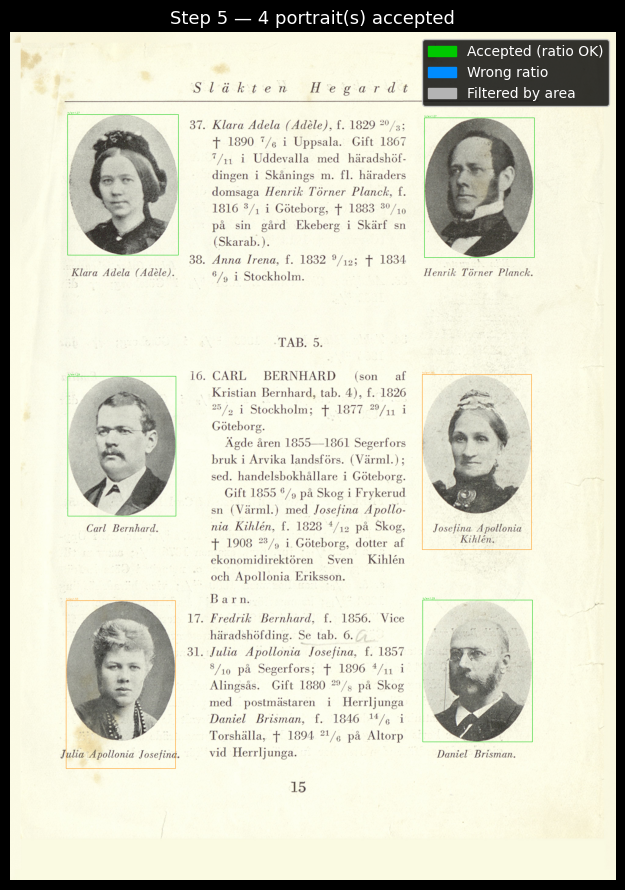

In [32]:
debug_filter = img.copy()
accepted = []  # list of (contour, ellipse, x, y, w, h)

for contour in large_contours:
    x, y, wc, hc = cv2.boundingRect(contour)
    cv2.rectangle(debug_filter, (x, y), (x+wc, y+hc), (180, 180, 180), 1)

    if len(contour) < 5:
        continue

    ellipse = cv2.fitEllipse(contour)
    x, y, wc, hc = cv2.boundingRect(contour)
    hw_ratio = hc / wc if wc > 0 else 0

    ratio_ok = abs(hw_ratio - TARGET_HW_RATIO) <= HW_TOLERANCE
    color = (0, 200, 0) if ratio_ok else (0, 140, 255)  # green / orange

    cv2.rectangle(debug_filter, (x, y), (x+wc, y+hc), color, 2)
    cv2.putText(debug_filter, f'h/w={hw_ratio:.2f}', (x, y - 6),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, cv2.LINE_AA)

    if ratio_ok:
        accepted.append((contour, ellipse, x, y, wc, hc))

patches = [
    mpatches.Patch(color='#00c800', label='Accepted (ratio OK)'),
    mpatches.Patch(color='#008cff', label='Wrong ratio'),
    mpatches.Patch(color='#b4b4b4', label='Filtered by area'),
]
show(debug_filter,
     title=f'Step 5 — {len(accepted)} portrait(s) accepted',
     figsize=(12, 9),
     legend_patches=patches)

## Step 6 — Crop & remove background

For each accepted portrait:
1. A filled ellipse mask is drawn from the fitted ellipse
2. The mask is used as the alpha channel → transparent RGBA PNG
3. The file is saved to `./contour_portraits/`

The three panels show: raw crop | ellipse mask | result composited on white.

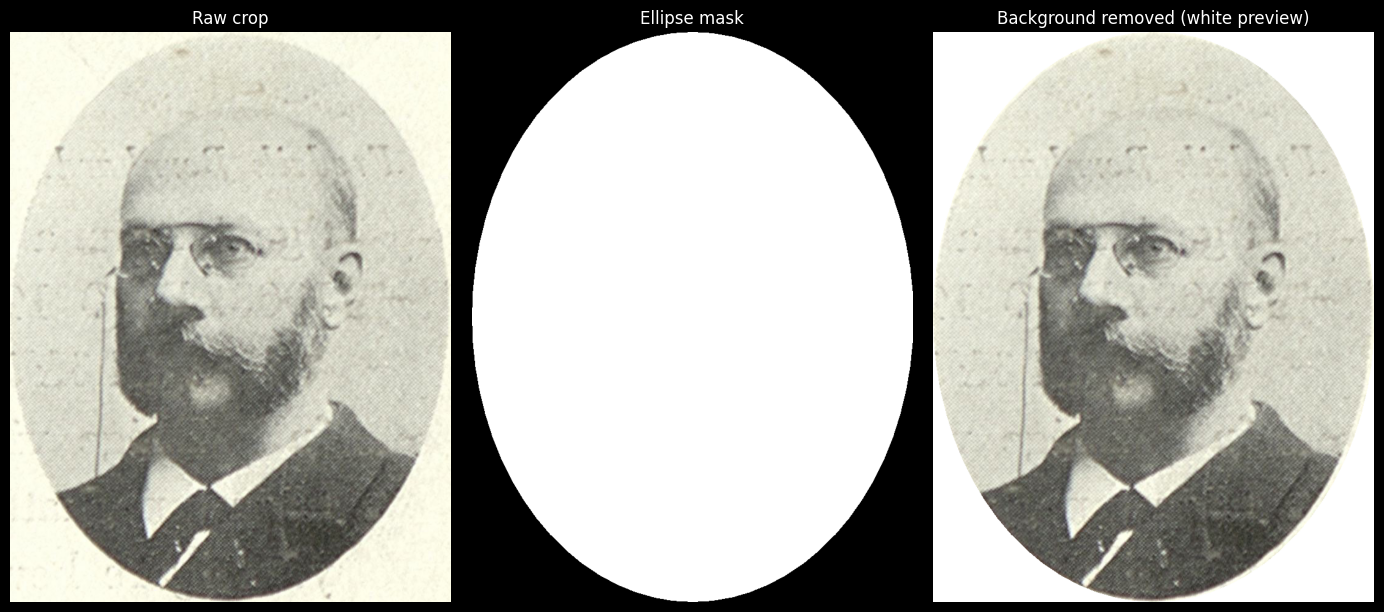

In [33]:
for portrait_num, (contour, ellipse, x, y, wc, hc) in enumerate(accepted):
    # Padded bounding box
    x1 = max(0, x - PADDING)
    y1 = max(0, y - PADDING)
    x2 = min(img.shape[1], x + wc + PADDING)
    y2 = min(img.shape[0], y + hc + PADDING)
    crop_bgr = img[y1:y2, x1:x2]

    # Fit ellipse exactly to the crop dimensions
    crop_h, crop_w = crop_bgr.shape[:2]
    cx_crop = crop_w // 2
    cy_crop = crop_h // 2
    semi_a = crop_w // 2  # horizontal semi-axis
    semi_b = crop_h // 2  # vertical semi-axis

    mask = np.zeros(crop_bgr.shape[:2], dtype=np.uint8)
    cv2.ellipse(mask, (cx_crop, cy_crop), (semi_a, semi_b),
                0, 0, 360, 255, thickness=-1)

    # Build RGBA: alpha = mask
    rgba = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2BGRA)
    rgba[:, :, 3] = mask

    # Composite on white for the preview (so transparency is obvious)
    white_bg   = np.full_like(crop_bgr, 255)
    mask_3ch   = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    composited = np.where(mask_3ch == 255, crop_bgr, white_bg).astype(np.uint8)

    fig, axes = plt.subplots(1, 3, figsize=(14, 6))
    axes[0].imshow(cv2.cvtColor(crop_bgr,   cv2.COLOR_BGR2RGB)); axes[0].set_title('Raw crop')
    axes[1].imshow(mask, cmap='gray');                            axes[1].set_title('Ellipse mask')
    axes[2].imshow(cv2.cvtColor(composited, cv2.COLOR_BGR2RGB)); axes[2].set_title('Background removed (white preview)')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()
    break

## Step 7 — Batch: process every page

Once you're happy with the sample-page results, run this cell to process all pages.

In [34]:
total_saved = 0

for page in sorted(PAGES_DIR.glob('*.png')):
    img_b = cv2.imread(str(page))
    if img_b is None:
        print(f'WARN: could not read {page}')
        continue

    gray_b    = cv2.cvtColor(img_b, cv2.COLOR_BGR2GRAY)
    blurred_b = cv2.GaussianBlur(gray_b, (5, 5), 0)
    _, thresh_b = cv2.threshold(blurred_b, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours_b, _ = cv2.findContours(thresh_b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    portrait_num = 0
    for contour in contours_b:
        area = cv2.contourArea(contour)
        if area < AREA_MIN or area > AREA_MAX or len(contour) < 5:
            continue

        ellipse  = cv2.fitEllipse(contour)
        x, y, wc, hc = cv2.boundingRect(contour)
        hw_ratio = hc / wc if wc > 0 else 0
        if abs(hw_ratio - TARGET_HW_RATIO) > HW_TOLERANCE:
            continue

        x1 = max(0, x - PADDING)
        y1 = max(0, y - PADDING)
        x2 = min(img_b.shape[1], x + wc + PADDING)
        y2 = min(img_b.shape[0], y + hc + PADDING)
        crop_b = img_b[y1:y2, x1:x2]

        (cx, cy), (ax1, ax2), angle = ellipse
        cx_c   = int(cx) - x1
        cy_c   = int(cy) - y1
        SHRINK = 3
        semi_a = max(1, int(ax1 / 2) - SHRINK)
        semi_b = max(1, int(ax2 / 2) - SHRINK)

        mask_b = np.zeros(crop_b.shape[:2], dtype=np.uint8)
        cv2.ellipse(mask_b, (cx_c, cy_c), (semi_a, semi_b),
                    angle, 0, 360, 255, thickness=-1)

        rgba_b = cv2.cvtColor(crop_b, cv2.COLOR_BGR2BGRA)
        rgba_b[:, :, 3] = mask_b

        out_path = OUTPUT_DIR / f'{page.stem}_{portrait_num}.png'
        cv2.imwrite(str(out_path), rgba_b)
        portrait_num += 1
        total_saved  += 1

    print(f'{page.stem}: {portrait_num} portrait(s) saved')

print(f'\nDone — {total_saved} portrait(s) total saved to {OUTPUT_DIR}/')

page_99: 0 portrait(s) saved

Done — 211 portrait(s) total saved to contour_portraits/
